# Overlap with transposable elements

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
mpra_alus = pl.read_csv(cd+"results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_alus_OA.tsv", separator="\t")
mpra_repeats = pl.read_csv(cd+"results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_repeat_families_OA.tsv", separator="\t")

In [3]:
mpra_repeats = mpra_repeats.filter(pl.col("promoter").is_null().not_()).with_columns(
	# Get unique, sorted OE_repeats
	pl.col("OE_repeats").str.split(",").list.unique().list.sort().list.join(",").alias("OE_repeats"),
	# Count occurrences of each OE_repeat
	pl.len().over("OE_repeats").alias("count")
)

In [ ]:
mpra_alus = mpra_alus.with_columns(
	pl.when((pl.col("promoter_alu") == "yes") & (pl.col("OE_alu") == "no")).then(pl.lit("alu in promoter"))
	.when((pl.col("OE_alu") == "yes") & (pl.col("promoter_alu") == "no")).then(pl.lit("alu in CRE"))
	.when((pl.col("OE_alu") == "yes") & (pl.col("promoter_alu") == "yes")).then(pl.lit("alu in promoter and CRE"))
	.otherwise(pl.lit("no alu")).alias("alu_location")
)

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(data=mpra_alus.filter(pl.col("effect")!="no effect").to_pandas(), x="z_score", hue="alu_location", bins=20, multiple="dodge", shrink=.8)

<Axes: xlabel='z_score', ylabel='Count'>

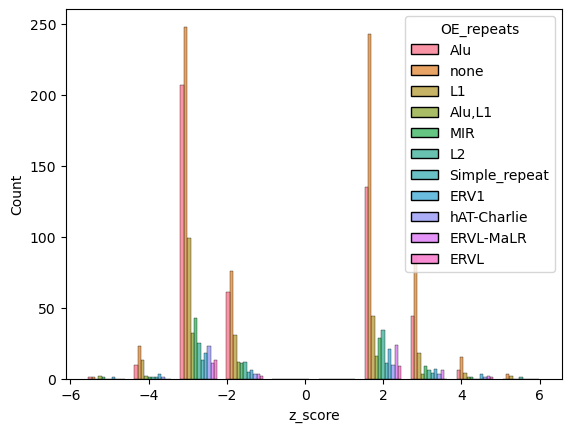

In [6]:
sns.histplot(data=mpra_repeats.filter(pl.col("effect")!="no effect")
			 .filter(pl.col("count")> 500).to_pandas(), x="z_score", hue="OE_repeats", bins=10, multiple="dodge", shrink=.8)

In [7]:
mpra_repeats.select(pl.col("OE_repeats"), pl.len().over("OE_repeats").alias("count")).unique().sort("count", descending=True)

OE_repeats,count
str,u32
"""none""",19831
"""Alu""",14452
"""L1""",4797
"""MIR""",2315
"""L2""",2216
…,…
"""ERVL,L2,Simple_repeat""",1
"""ERVK,L2""",1
"""hAT-Charlie,tRNA-RTE""",1


In [8]:
mpra_repeats.filter(pl.col("effect")!="no effect") \
			.select("effect",pl.col("OE_repeats"), pl.len().over("OE_repeats","effect").alias("count")/pl.len().over("effect"))

effect,OE_repeats,count
str,str,f64
"""downregulating""","""Alu""",0.223022
"""downregulating""","""Alu""",0.223022
"""upregulating""","""none""",0.392777
"""downregulating""","""none""",0.278177
"""downregulating""","""L1""",0.114309
…,…,…
"""upregulating""","""ERVL-MaLR""",0.036117
"""downregulating""","""Alu,ERVL""",0.001599
"""upregulating""","""MIR""",0.044018


<Axes: xlabel='fraction', ylabel='OE_repeats'>

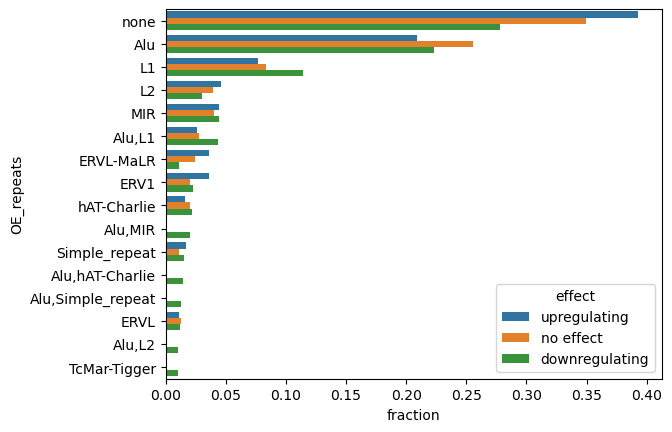

In [9]:
sns.barplot(mpra_repeats
			#.filter(pl.col("effect")!="no effect")
			.select("effect",pl.col("OE_repeats"), pl.len().over("OE_repeats","effect").alias("fraction")/pl.len().over("effect")).unique().sort("fraction", descending=True)
			.filter(pl.col("fraction")>0.01).to_pandas(),
			x="fraction", y="OE_repeats", orient='h', hue="effect")

In [4]:
# Now ungrouping different classes

mpra_repeats_exploded = mpra_repeats.with_columns(
	pl.col("OE_repeats").str.split(",").alias("OE_repeats_exploded")
).explode("OE_repeats_exploded")

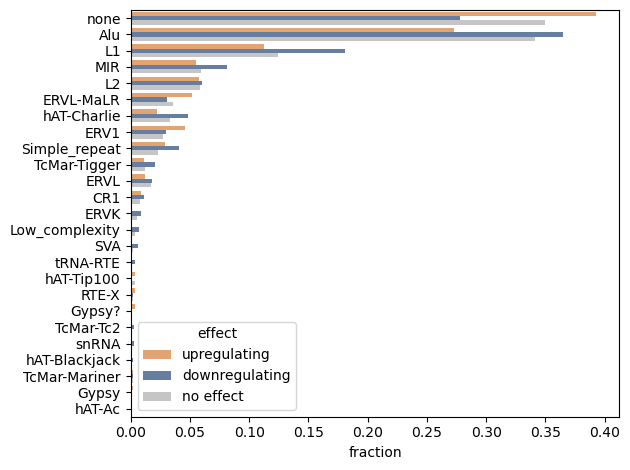

In [13]:
sns.barplot(mpra_repeats_exploded
			#.filter(pl.col("effect")!="no effect")
			.select("effect",pl.col("OE_repeats_exploded"), 
		   # Making sure to count unique interactions for fraction, since we can now have the same interaction in the dataset multiple times
		   pl.len().over("OE_repeats_exploded","effect").alias("fraction")/(pl.col("left_bin")+pl.col("right_bin")).n_unique().over("effect")).unique()
		   .sort("fraction", descending=True)
			.filter(pl.col("fraction")>0.001).to_pandas(),
			x="fraction", y="OE_repeats_exploded", orient='h', hue="effect", palette=["#F4A261","#5D7CA8", "#c5c5c5"])
plt.ylabel("")
plt.tight_layout()
plt.savefig(cd+"results/manuscript_figures/revisions/repeat_elements/repeat_family_enrichment_barplot.pdf", format="pdf")

In [17]:
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact

repeat_counts = mpra_repeats_exploded.select("effect", "OE_repeats_exploded", pl.len().over("OE_repeats_exploded","effect").alias("count")).unique()
total_counts = mpra_repeats_exploded.select("effect",(pl.col("left_bin")+pl.col("right_bin")).n_unique().over("effect").alias("total")).unique()
results = []
repeat_classes = repeat_counts["OE_repeats_exploded"].unique().to_list()

for repeat_class in repeat_classes:
	# counts: [overlaps, not overlaps]
	enhancers = [
		repeat_counts.filter((pl.col("effect") == "upregulating") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "upregulating") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "upregulating")["total"].item()
	]
	silencers = [
		repeat_counts.filter((pl.col("effect") == "downregulating") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "downregulating") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "downregulating")["total"].item()
	]
	other = [
		repeat_counts.filter((pl.col("effect") == "no effect") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "no effect") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "no effect")["total"].item()
	]

	table = np.array([enhancers, silencers, other]).T

	try:
		chi2, p, dof, expected = chi2_contingency(table)
	except Exception as e:
		chi2, p, dof, expected = np.nan, np.nan, np.nan, np.nan

	try:
		oddsratio, pAB = fisher_exact([[enhancers[0], enhancers[1]], [silencers[0], silencers[1]]])
		oddsratio, pAC = fisher_exact([[enhancers[0], enhancers[1]], [other[0], other[1]]])
		oddsratio, pBC = fisher_exact([[silencers[0], silencers[1]], [other[0], other[1]]])
	except Exception as e:
		pAB, pAC, pBC = np.nan, np.nan, np.nan

	results.append({
		"repeat_class": repeat_class,
		"chi2_p": p,
		"fisher_enh_vs_sil_p": pAB,
		"fisher_enh_vs_other_p": pAC,
		"fisher_sil_vs_other_p": pBC
	})

# Display the dataframe in a more readable format in Jupyter
pl.Config.set_tbl_rows(50)
pl.DataFrame(results)


repeat_class,chi2_p,fisher_enh_vs_sil_p,fisher_enh_vs_other_p,fisher_sil_vs_other_p
str,f64,f64,f64,f64
"""rRNA""",0.545842,1.0,1.0,1.0
"""Alu""",0.00435,0.001557,0.002139,0.237908
"""Helitron?""",0.961693,1.0,1.0,1.0
"""L1""",0.000001,0.000208,0.411933,8.9963e-7
"""hAT-Tip100?""",0.906965,1.0,1.0,1.0
"""srpRNA""",0.650731,1.0,1.0,1.0
"""hAT-Blackjack""",0.198094,0.271838,1.0,0.140569
"""scRNA""",0.574155,1.0,1.0,0.349381
"""TcMar-Tigger""",0.033433,0.12383,1.0,0.014622
